## imports

In [38]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import UnivariateSpline
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

## paths and settings

In [39]:
RAW_CSV = Path(r"../data/raw/width_sweep_selected/all_widths_guided_modes.csv")

OUT_DIR = Path(r"../data/processed/width_sweep_selected")
OUT_DIR.mkdir(parents=True, exist_ok=True)

NEFF_CUTOFF = 1.4501
TE_THRESHOLD = 0.5

N_HIGH_RES = 10000
SPLINE_SMOOTHING = 0

## load CSV

In [40]:
raw = pd.read_csv(
    RAW_CSV,
    engine="python",
    on_bad_lines="skip"
)

print("Raw shape:", raw.shape)
raw.head()

Raw shape: (66, 14)


,width_um,thickness_um,wavelength_um,mode,n_eff,n_g,mode_area_um2,xbar_um,ybar_um,mfd_x_um,mfd_y_um,TE_fraction,n_core,n_clad
0,0.400000,0.35,1.55,0,1.469177,1.603790,11.898572,-0.001556,0.004041,2.356106,1.831838,0.994377,1.97439,1.450066
1,0.400000,0.35,1.55,1,1.466174,1.584208,12.860904,0.004765,-0.001566,2.348606,2.039726,0.005180,1.97439,1.450066
2,0.505263,0.35,1.55,0,1.493223,1.721447,7.633692,-0.001092,0.004499,1.827097,1.448711,0.992282,1.97439,1.450066
3,0.505263,0.35,1.55,1,1.479446,1.653668,9.463506,0.004817,-0.001877,1.916013,1.767409,0.006820,1.97439,1.450066
4,0.610526,0.35,1.55,0,1.520065,1.812893,5.918703,-0.000600,0.004701,1.586510,1.246119,0.992007,1.97439,1.450066


## create output folders

In [41]:
file_out_dir = OUT_DIR / RAW_CSV.stem
file_out_dir.mkdir(parents=True, exist_ok=True)

plot_dir = file_out_dir / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

print("Output folder:", file_out_dir)

Output folder: ..\data\processed\width_sweep_selected\all_widths_guided_modes


## clean numeric data

In [42]:
def parse_complex_real(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    try:
        return float(x)
    except ValueError:
        pass

    try:
        return complex(x.replace("i", "j")).real
    except ValueError:
        return np.nan

## normalize columns

In [43]:
clean = raw.copy()

# Rename Tidy3D sweep columns to match your old cleaner style
rename_map = {
    "mode": "mode_number",
    "n_eff": "neff",
    "n_g": "group_index",
    "mfd_x_um": "MFD_E2_x_um",
    "mfd_y_um": "MFD_E2_y_um",
}

clean = clean.rename(columns=rename_map)

needed_cols = [
    "width_um",
    "mode_number",
    "neff",
    "group_index",
    "TE_fraction",
    "mode_area_um2",
    "MFD_E2_x_um",
    "MFD_E2_y_um",
]

clean = clean[needed_cols].copy()

for col in needed_cols:
    clean[col] = clean[col].apply(parse_complex_real)

clean = clean.dropna(subset=["width_um", "mode_number"])
clean = clean.sort_values(["width_um", "mode_number"]).reset_index(drop=True)

print("Clean shape:", clean.shape)
clean.head(20)

Clean shape: (66, 8)


,width_um,mode_number,neff,group_index,TE_fraction,mode_area_um2,MFD_E2_x_um,MFD_E2_y_um
0,0.400000,0.0,1.469177,1.603790,0.994377,11.898572,2.356106,1.831838
1,0.400000,1.0,1.466174,1.584208,0.005180,12.860904,2.348606,2.039726
2,0.505263,0.0,1.493223,1.721447,0.992282,7.633692,1.827097,1.448711
3,0.505263,1.0,1.479446,1.653668,0.006820,9.463506,1.916013,1.767409
4,0.610526,0.0,1.520065,1.812893,0.992007,5.918703,1.586510,1.246119
5,0.610526,1.0,1.492874,1.708048,0.007709,8.023374,1.691013,1.625660
6,0.715789,0.0,1.545319,1.873054,0.992829,5.065813,1.479817,1.127691
7,0.715789,1.0,1.505235,1.747984,0.008046,7.326214,1.582912,1.540872
8,0.821053,0.0,1.567245,1.909627,0.994023,4.636718,1.430318,1.053234
9,0.821053,1.0,1.516143,1.776730,0.007986,7.032441,1.530409,1.484388


## classify TE/TM and track physical modes

In [44]:
clean["polarization"] = np.where(clean["TE_fraction"] >= TE_THRESHOLD, "TE", "TM")
clean.loc[clean["TE_fraction"].isna(), "polarization"] = np.nan

pol_order = {"TE": 0, "TM": 1}
clean["pol_order"] = clean["polarization"].map(pol_order)

# TE first, then TM; inside each polarization sort by neff descending
clean = clean.sort_values(
    ["width_um", "pol_order", "neff"],
    ascending=[True, True, False],
).reset_index(drop=True)

clean["mode_order_in_pol"] = (
    clean
    .groupby(["width_um", "polarization"])
    .cumcount() + 1
)

clean["tracked_mode"] = (
    clean["polarization"] + clean["mode_order_in_pol"].astype("Int64").astype(str)
)

clean.loc[clean["polarization"].isna(), "tracked_mode"] = np.nan

clean["old_mode_number"] = clean["mode_number"]
clean["mode_number"] = clean["mode_order_in_pol"]

clean = clean.drop(columns=["pol_order"])

raw_out_path = file_out_dir / "cleaned_raw_sorted_tracked.csv"
clean.to_csv(raw_out_path, index=False)

print("Saved:", raw_out_path)
clean.head(20)

Saved: ..\data\processed\width_sweep_selected\all_widths_guided_modes\cleaned_raw_sorted_tracked.csv


,width_um,mode_number,neff,group_index,TE_fraction,mode_area_um2,MFD_E2_x_um,MFD_E2_y_um,polarization,mode_order_in_pol,tracked_mode,old_mode_number
0,0.400000,1,1.469177,1.603790,0.994377,11.898572,2.356106,1.831838,TE,1,TE1,0.0
1,0.400000,1,1.466174,1.584208,0.005180,12.860904,2.348606,2.039726,TM,1,TM1,1.0
2,0.505263,1,1.493223,1.721447,0.992282,7.633692,1.827097,1.448711,TE,1,TE1,0.0
3,0.505263,1,1.479446,1.653668,0.006820,9.463506,1.916013,1.767409,TM,1,TM1,1.0
4,0.610526,1,1.520065,1.812893,0.992007,5.918703,1.586510,1.246119,TE,1,TE1,0.0
5,0.610526,1,1.492874,1.708048,0.007709,8.023374,1.691013,1.625660,TM,1,TM1,1.0
6,0.715789,1,1.545319,1.873054,0.992829,5.065813,1.479817,1.127691,TE,1,TE1,0.0
7,0.715789,1,1.505235,1.747984,0.008046,7.326214,1.582912,1.540872,TM,1,TM1,1.0
8,0.821053,1,1.567245,1.909627,0.994023,4.636718,1.430318,1.053234,TE,1,TE1,0.0
9,0.821053,1,1.516143,1.776730,0.007986,7.032441,1.530409,1.484388,TM,1,TM1,1.0


## spline fitting function

In [45]:
fit_params = [
    "neff",
    "group_index",
    "TE_fraction",
    "mode_area_um2",
    "MFD_E2_x_um",
    "MFD_E2_y_um",
]


def spline_fit_tracked_mode(df_mode):
    df_mode = df_mode.sort_values("width_um")

    df_fit = df_mode.dropna(subset=["width_um", "neff"])
    df_fit = df_fit[df_fit["neff"] >= NEFF_CUTOFF]

    if len(df_fit) < 4:
        return None

    x = df_fit["width_um"].to_numpy()
    x_hr = np.linspace(x.min(), x.max(), N_HIGH_RES)

    out = pd.DataFrame({
        "width_um": x_hr,
        "tracked_mode": df_mode["tracked_mode"].iloc[0],
        "polarization": df_mode["polarization"].iloc[0],
        "mode_number": df_mode["mode_number"].iloc[0],
    })

    for param in fit_params:
        valid = df_fit[["width_um", param]].dropna()

        if len(valid) < 4:
            out[param] = np.nan
            continue

        x_valid = valid["width_um"].to_numpy()
        y_valid = valid[param].to_numpy()

        spline = UnivariateSpline(
            x_valid,
            y_valid,
            s=SPLINE_SMOOTHING,
        )

        out[param] = spline(x_hr)

    out = out[out["neff"] >= NEFF_CUTOFF].copy()

    return out

## fit all tracked modes

In [46]:
high_res_list = []

for tracked_mode, df_mode in clean.dropna(subset=["tracked_mode"]).groupby("tracked_mode"):
    fitted = spline_fit_tracked_mode(df_mode)

    if fitted is not None and len(fitted) > 0:
        high_res_list.append(fitted)

if not high_res_list:
    raise RuntimeError("No tracked modes had enough valid points for spline fitting.")

high_res = pd.concat(high_res_list, ignore_index=True)

high_res = high_res.sort_values(
    ["width_um", "polarization", "mode_number"]
).reset_index(drop=True)

print("High-res shape:", high_res.shape)
high_res.head()

High-res shape: (50000, 10)


,width_um,tracked_mode,polarization,mode_number,neff,group_index,TE_fraction,mode_area_um2,MFD_E2_x_um,MFD_E2_y_um
0,0.4000,TE1,TE,1,1.469177,1.603790,0.994377,11.898572,2.356106,1.831838
1,0.4000,TM1,TM,1,1.466174,1.584208,0.005180,12.860904,2.348606,2.039726
2,0.4002,TE1,TE,1,1.469217,1.604033,0.994371,11.886778,2.354719,1.830869
3,0.4002,TM1,TM,1,1.466198,1.584354,0.005184,12.851678,2.347528,2.039031
4,0.4004,TE1,TE,1,1.469257,1.604277,0.994364,11.875001,2.353334,1.829902


## save high-res fitted data

In [47]:
high_res_out_path = file_out_dir / "cleaned_high_res_spline.csv"
high_res.to_csv(high_res_out_path, index=False)

print("Saved:", high_res_out_path)

Saved: ..\data\processed\width_sweep_selected\all_widths_guided_modes\cleaned_high_res_spline.csv


## plot helper

In [48]:
def plot_colored_line(ax, x, y, c, linewidth=2):
    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(c)

    x = x[valid]
    y = y[valid]
    c = c[valid]

    if len(x) < 2:
        return None

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    lc = LineCollection(
        segments,
        cmap="coolwarm",
        norm=Normalize(0, 1),
        linewidth=linewidth,
    )

    lc.set_array(c[:-1])
    ax.add_collection(lc)
    ax.autoscale()

    return lc

## plot all parameters

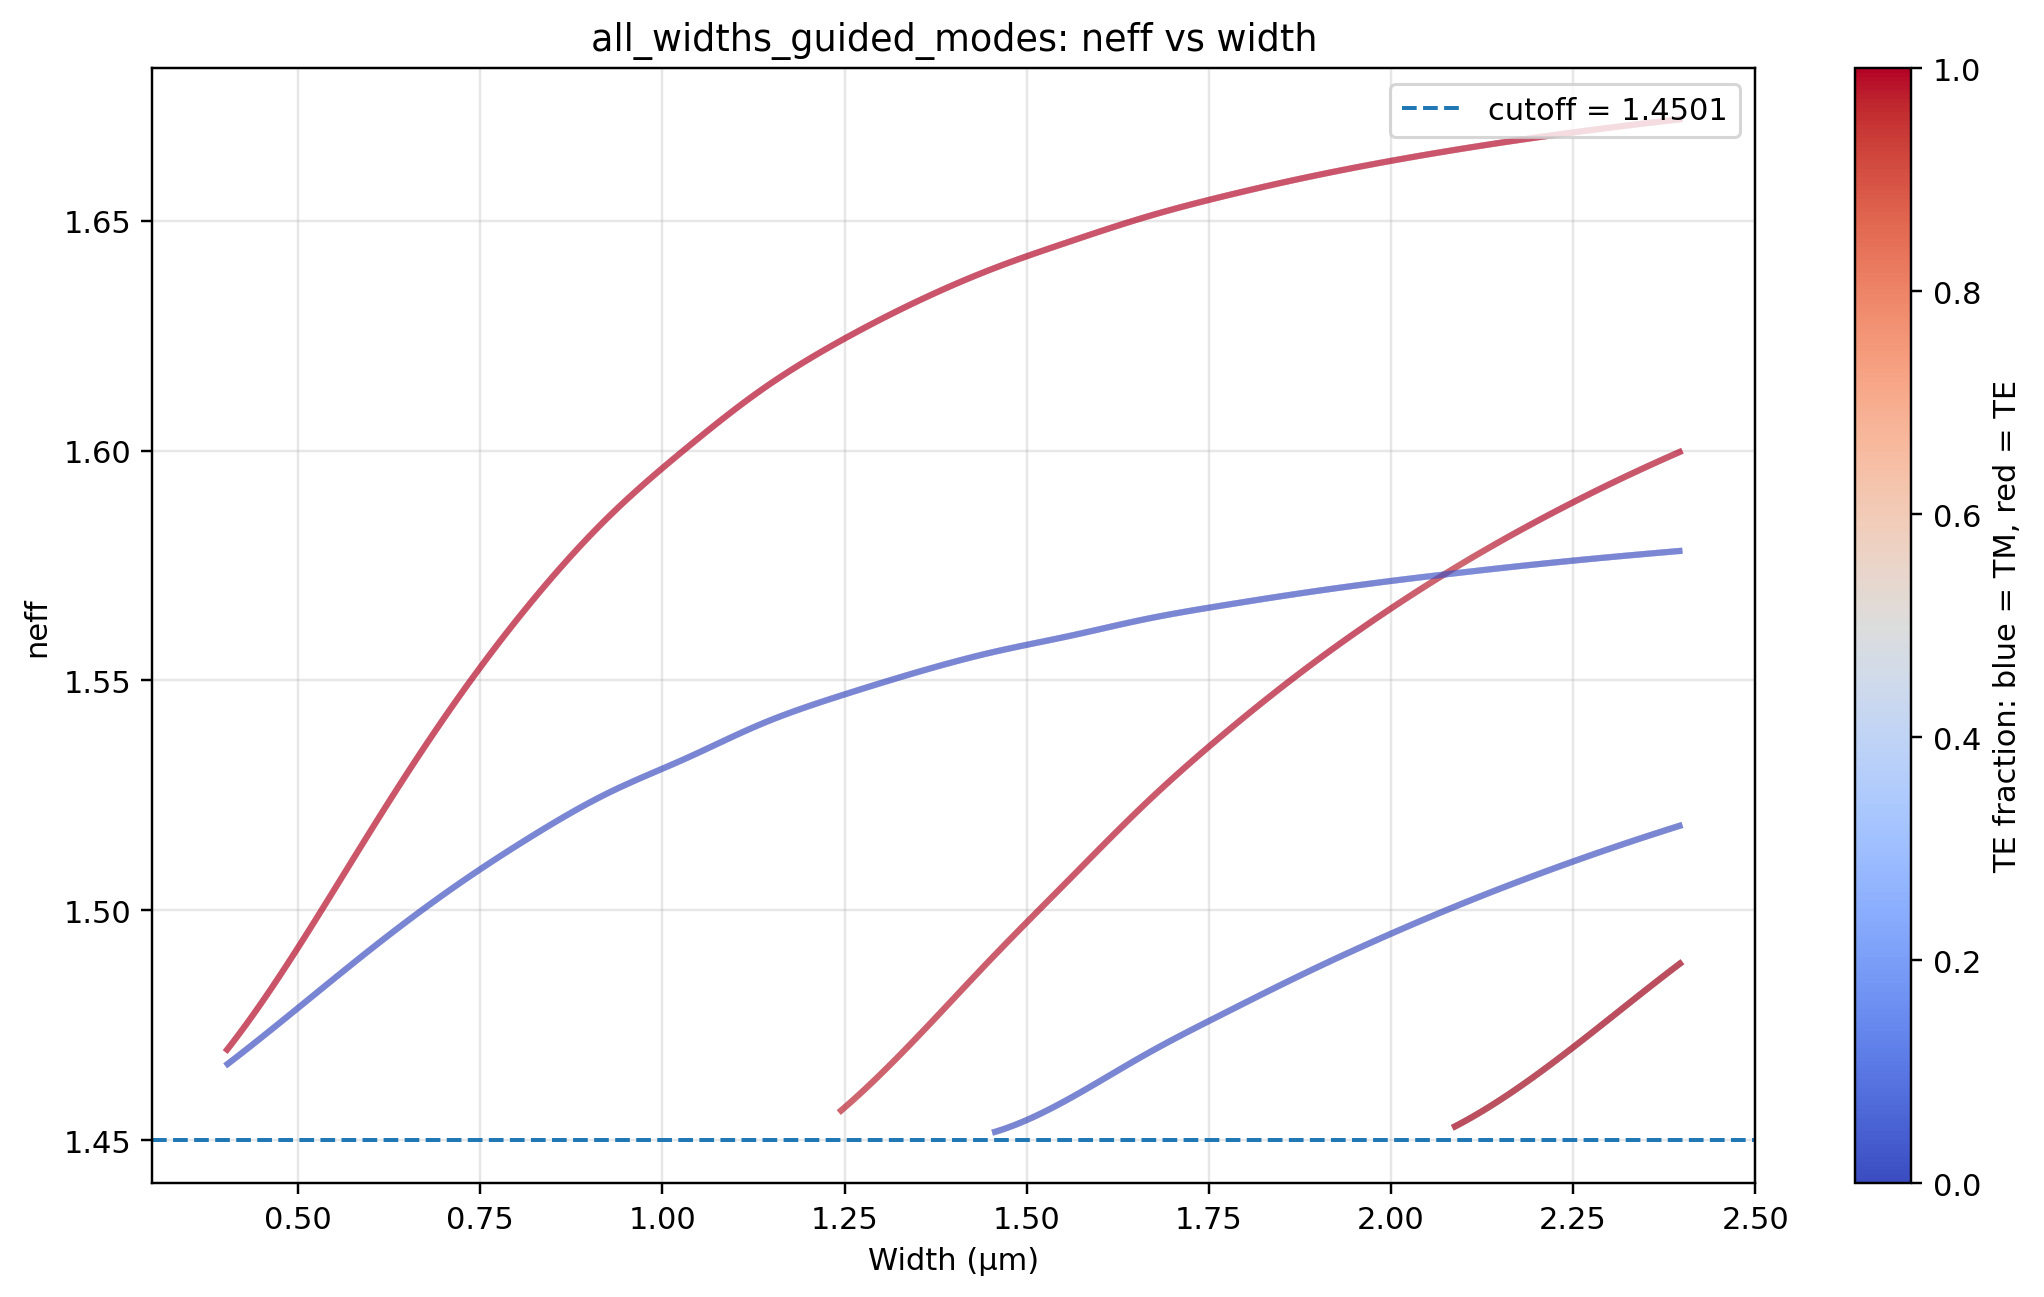

Saved: ..\data\processed\width_sweep_selected\all_widths_guided_modes\plots\neff_tracked_vs_width.png


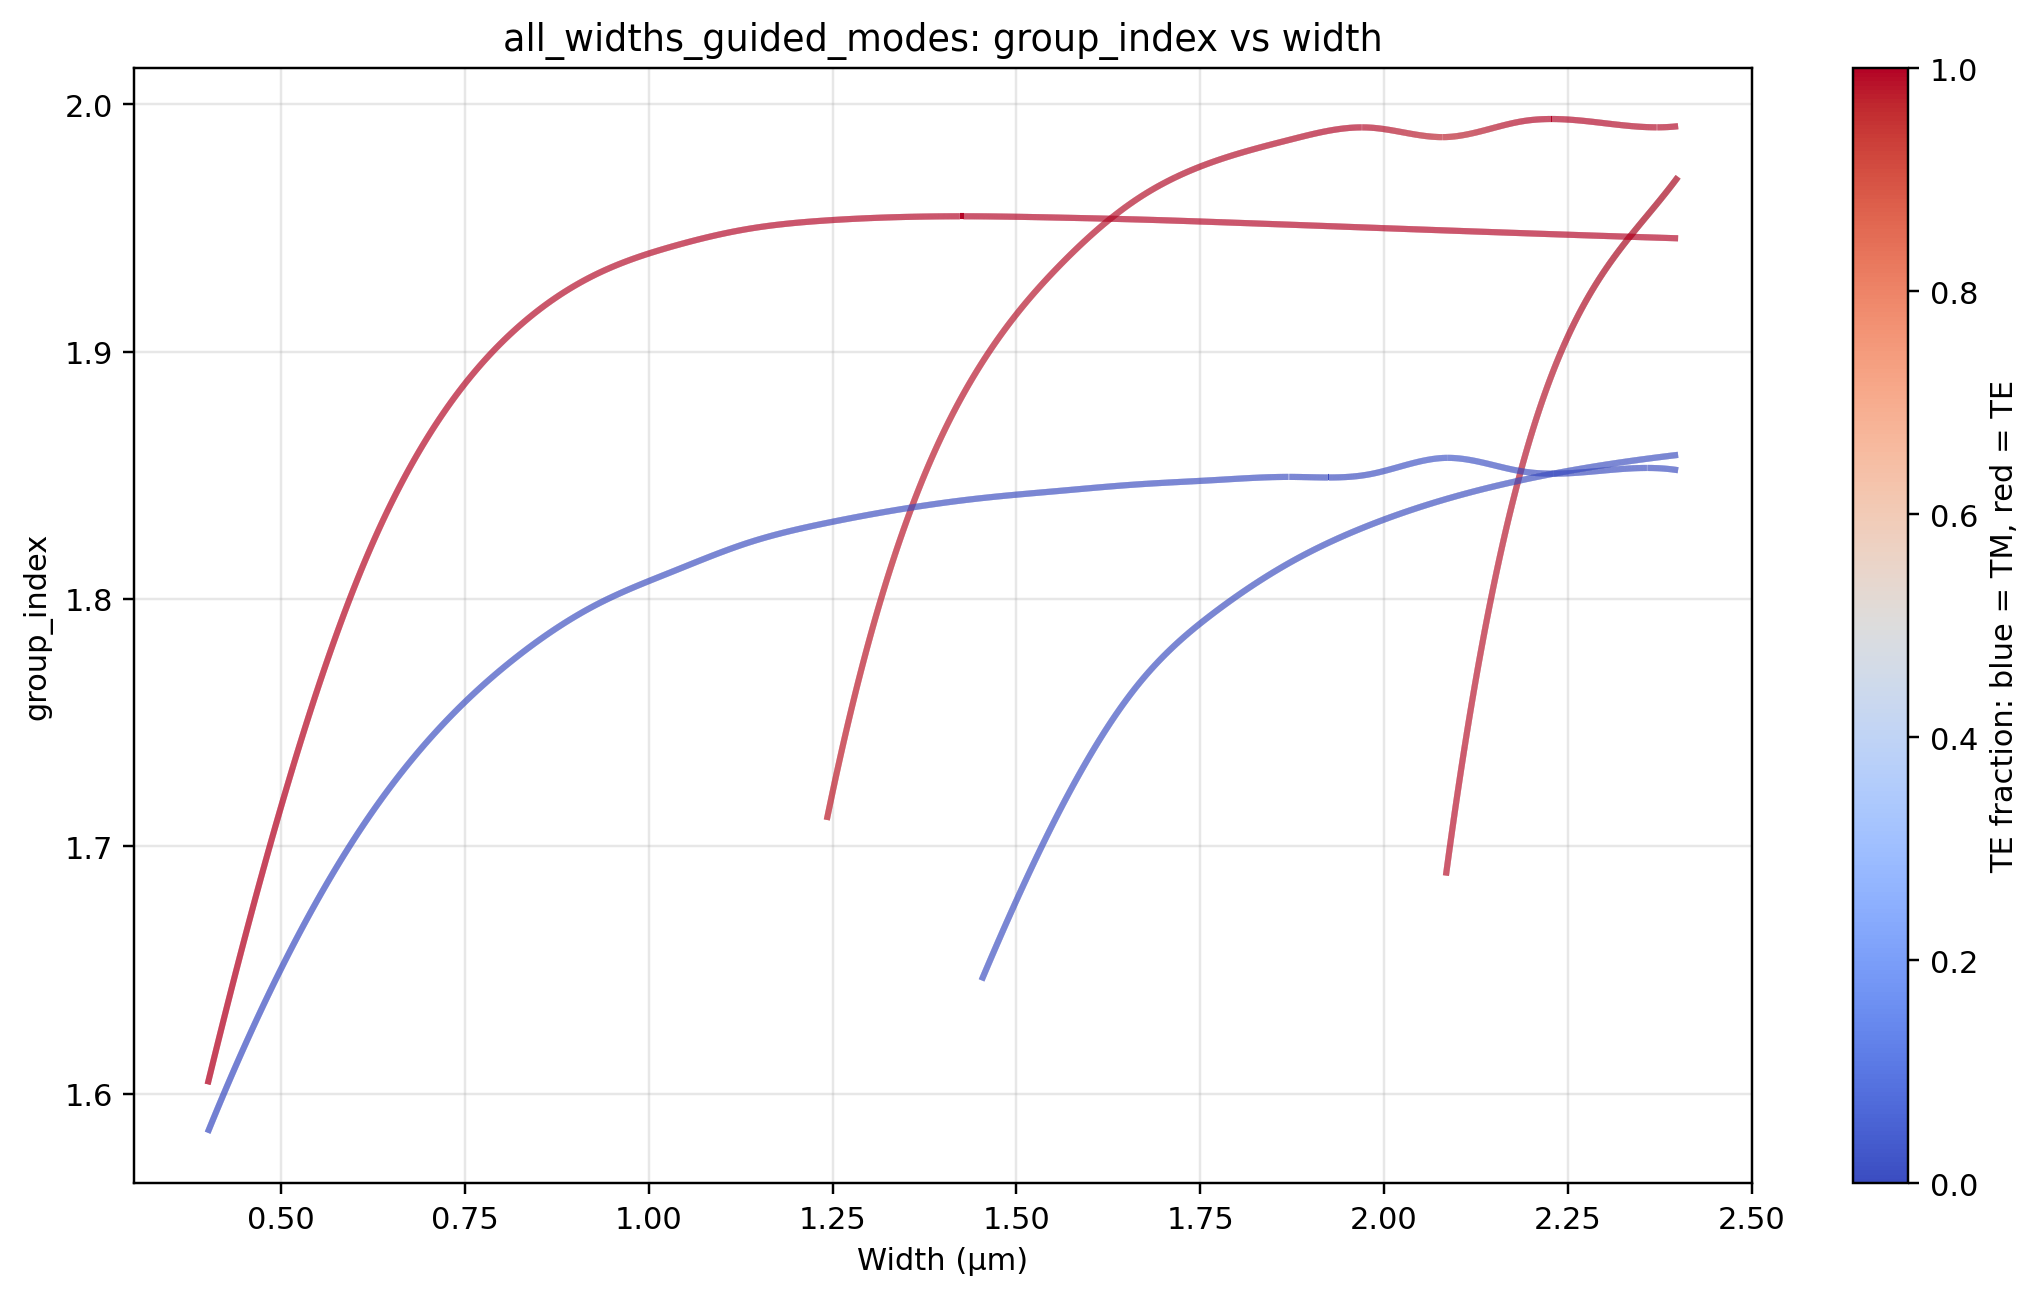

Saved: ..\data\processed\width_sweep_selected\all_widths_guided_modes\plots\group_index_tracked_vs_width.png


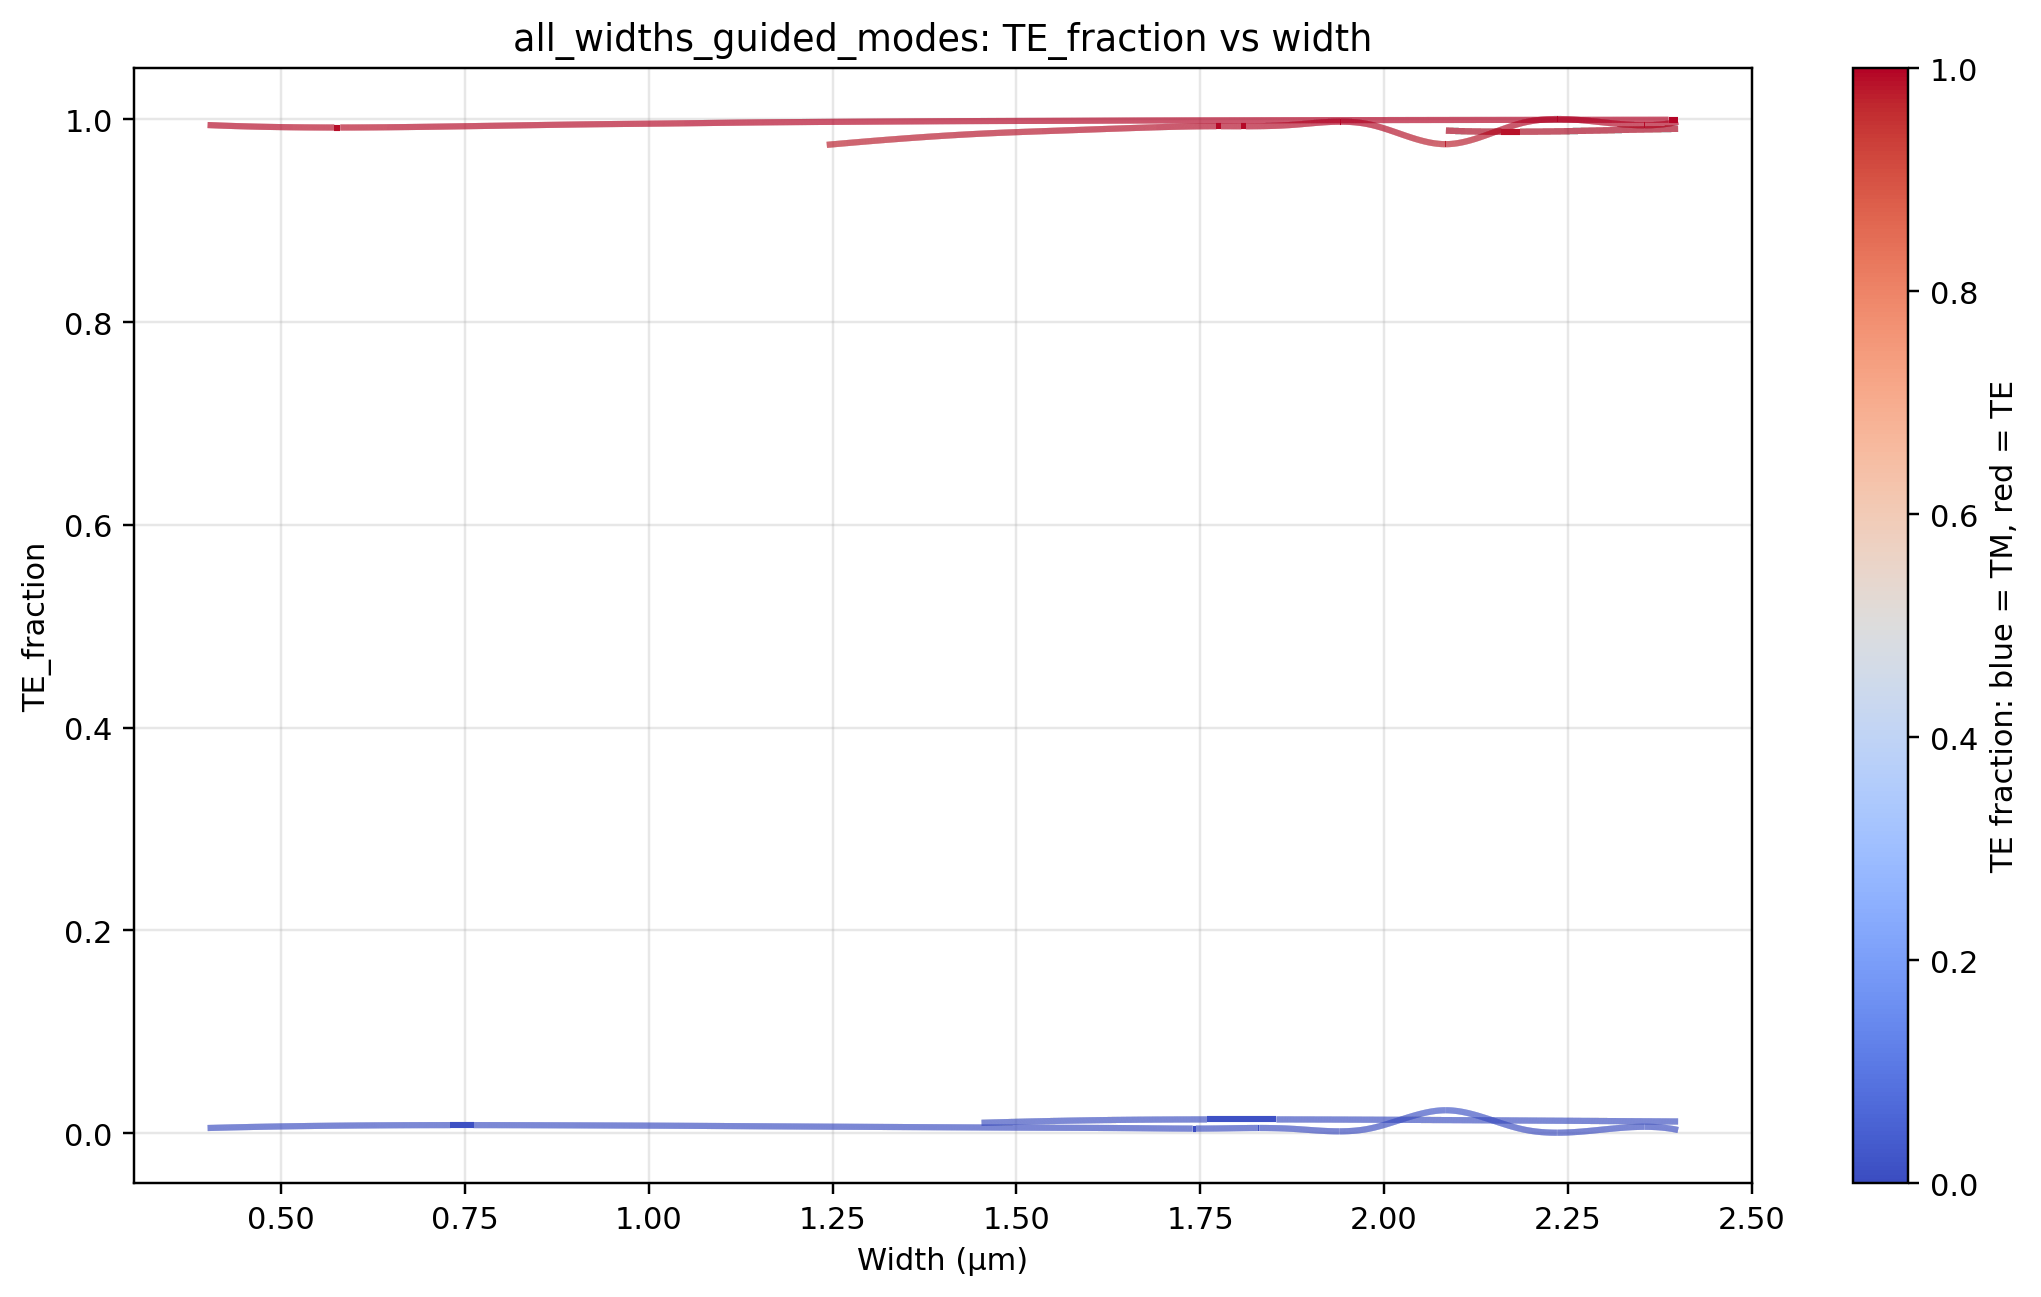

Saved: ..\data\processed\width_sweep_selected\all_widths_guided_modes\plots\TE_fraction_tracked_vs_width.png


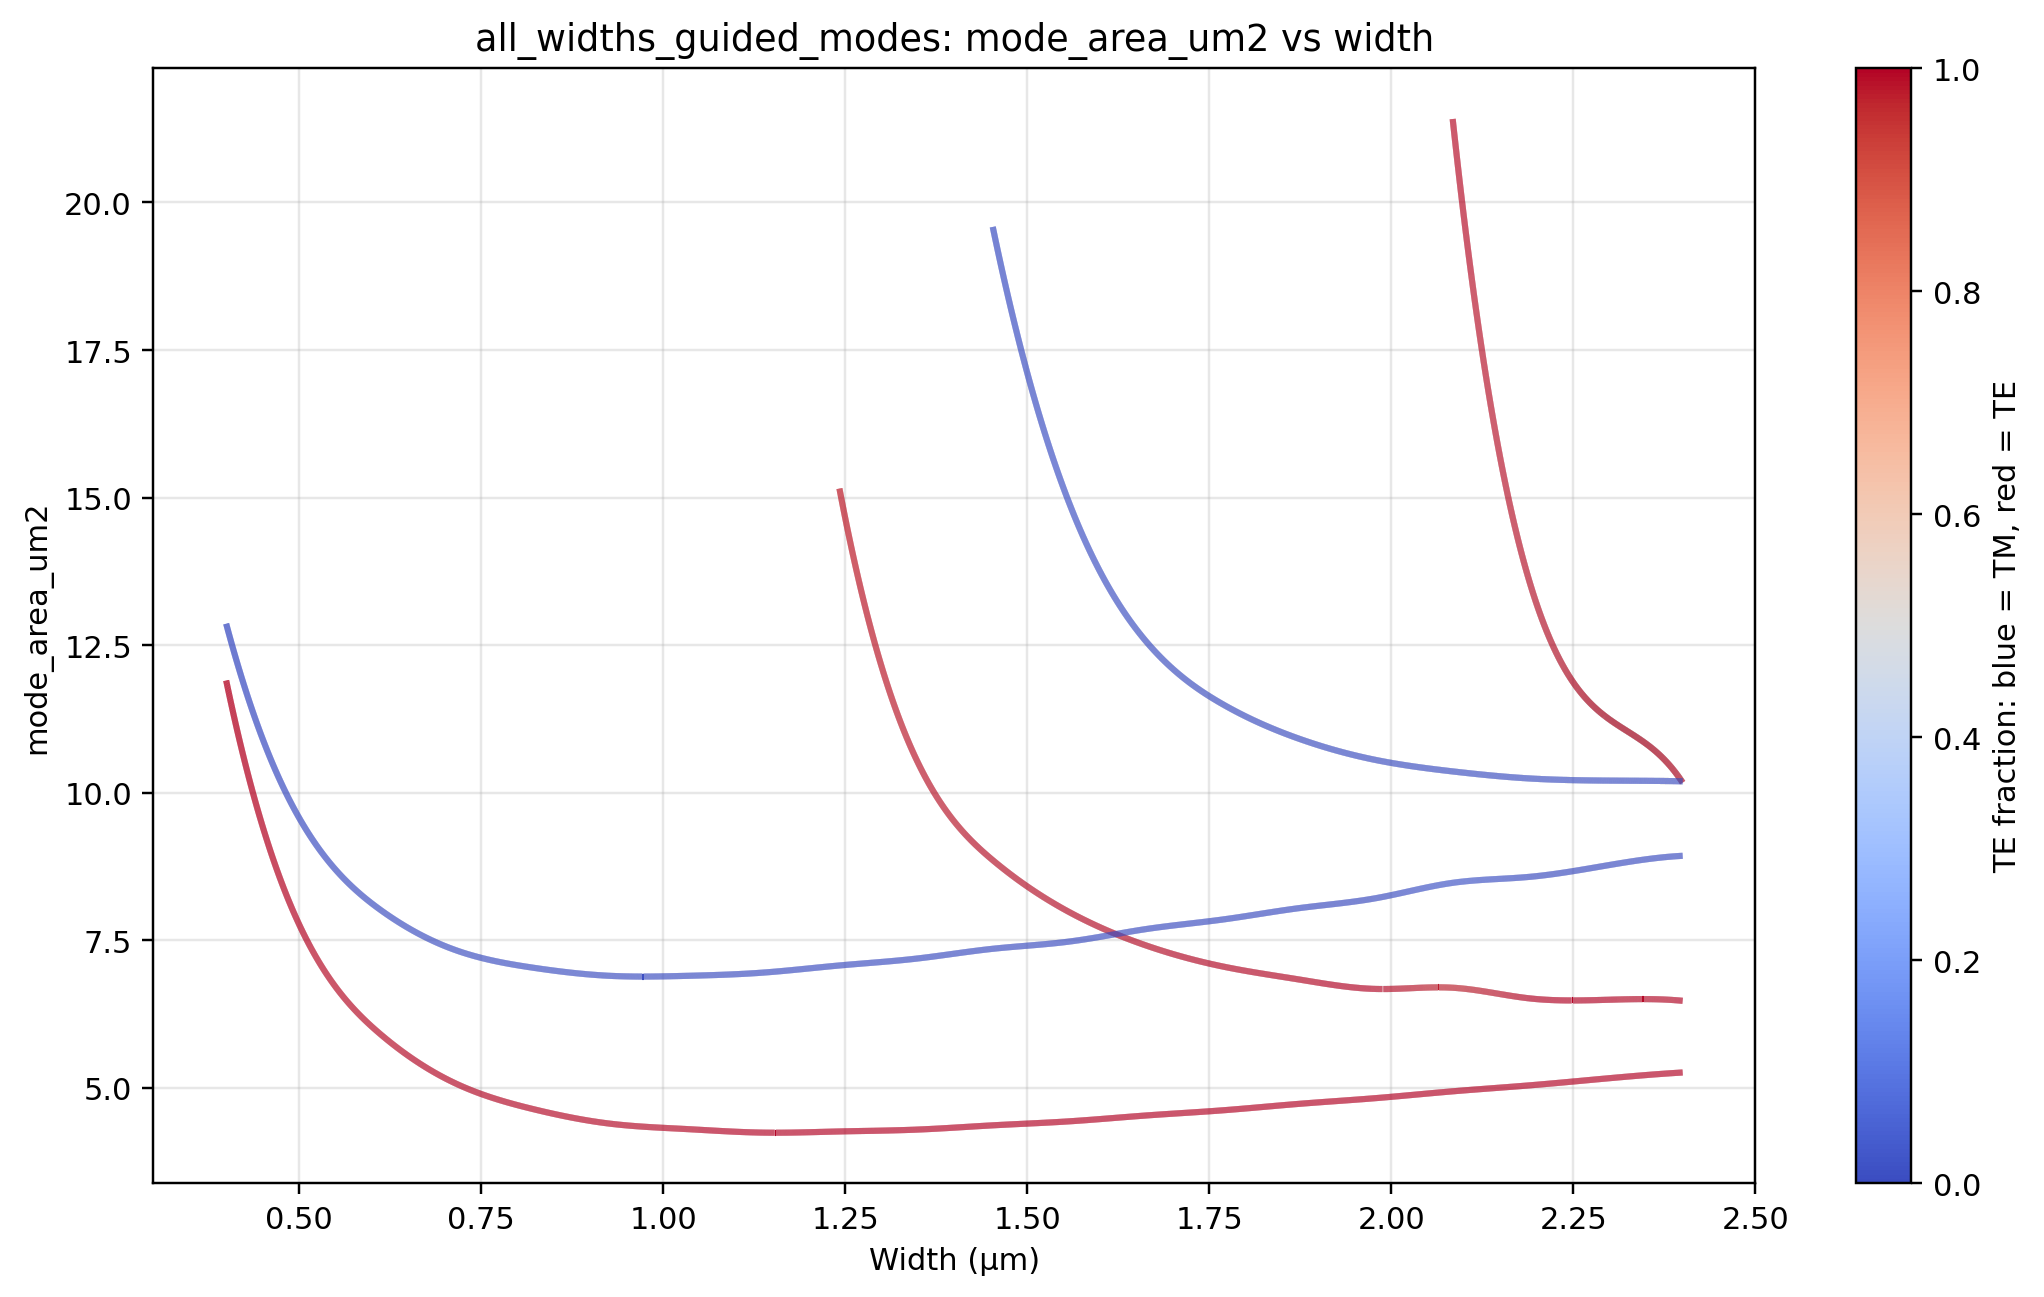

Saved: ..\data\processed\width_sweep_selected\all_widths_guided_modes\plots\mode_area_um2_tracked_vs_width.png


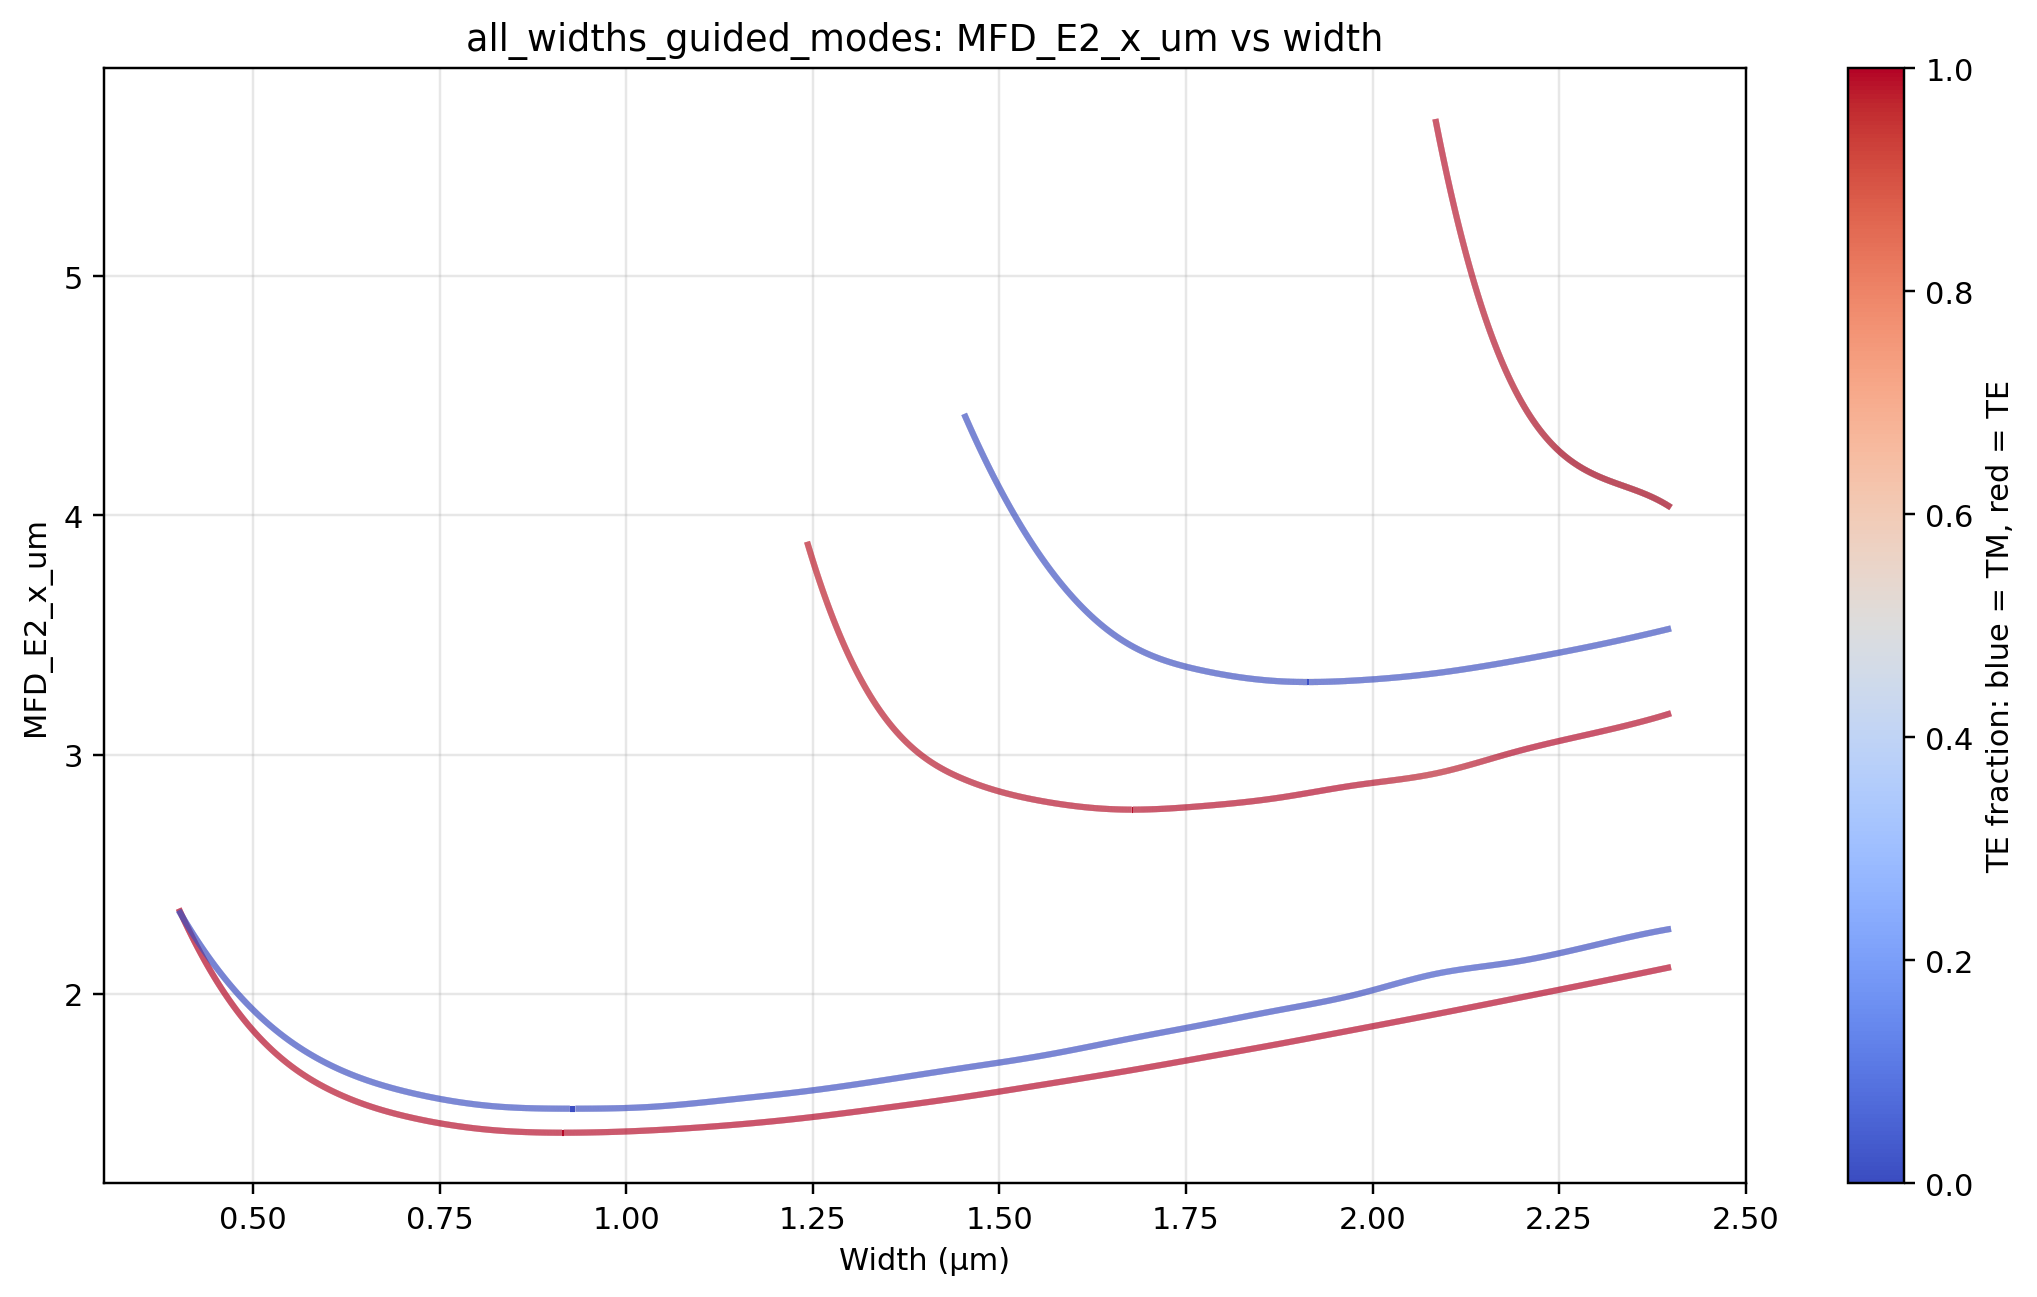

Saved: ..\data\processed\width_sweep_selected\all_widths_guided_modes\plots\MFD_E2_x_um_tracked_vs_width.png


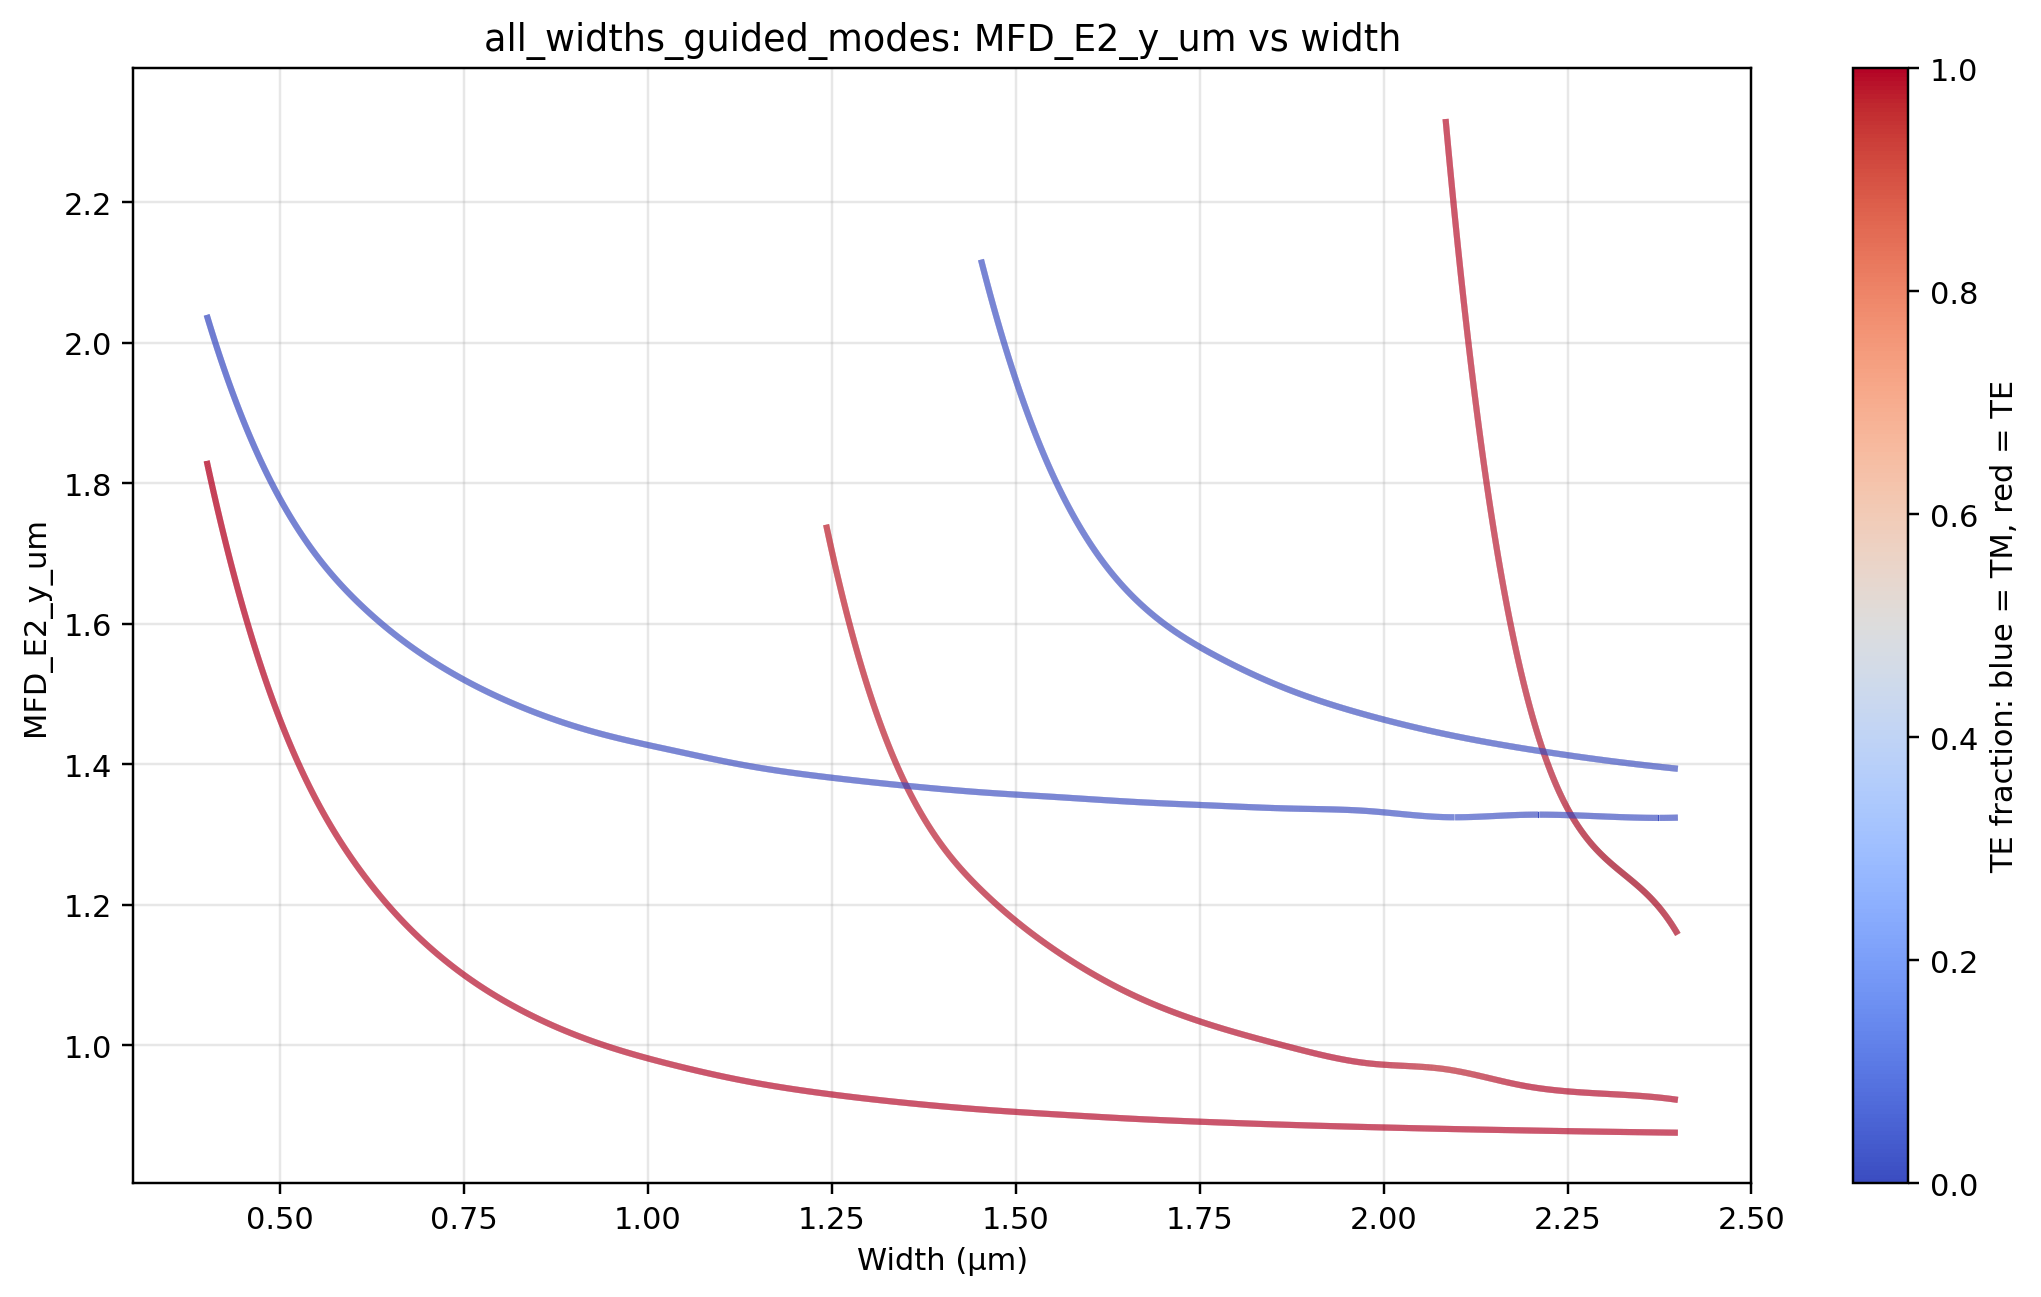

Saved: ..\data\processed\width_sweep_selected\all_widths_guided_modes\plots\MFD_E2_y_um_tracked_vs_width.png


In [49]:
for param in fit_params:
    fig, ax = plt.subplots(figsize=(10, 6), dpi=220)

    last_lc = None

    for tracked_mode, df_mode in high_res.groupby("tracked_mode"):
        df_mode = df_mode.sort_values("width_um")

        x = df_mode["width_um"].to_numpy()
        y = df_mode[param].to_numpy()
        c = df_mode["TE_fraction"].clip(0, 1).to_numpy()

        lc = plot_colored_line(ax, x, y, c)

        if lc is not None:
            last_lc = lc

    if param == "neff":
        ax.axhline(
            NEFF_CUTOFF,
            linestyle="--",
            linewidth=1.3,
            label=f"cutoff = {NEFF_CUTOFF}",
        )
        ax.legend()

    ax.set_xlabel("Width (µm)")
    ax.set_ylabel(param)
    ax.set_title(f"{RAW_CSV.stem}: {param} vs width")
    ax.grid(True, alpha=0.3)

    if last_lc is not None:
        cbar = fig.colorbar(last_lc, ax=ax)
        cbar.set_label("TE fraction: blue = TM, red = TE")

    fig.tight_layout()

    save_path = plot_dir / f"{param}_tracked_vs_width.png"
    fig.savefig(save_path, dpi=300)
    plt.show()

    print("Saved:", save_path)

## quick summary

In [50]:
print("Cleaned raw:", raw_out_path)
print("High-res spline:", high_res_out_path)
print("Plots:", plot_dir)

display_cols = [
    "tracked_mode",
    "polarization",
    "mode_number",
    "width_um",
    "neff",
    "group_index",
    "TE_fraction",
    "mode_area_um2",
    "MFD_E2_x_um",
    "MFD_E2_y_um",
]

high_res[display_cols].head(20)

Cleaned raw: ..\data\processed\width_sweep_selected\all_widths_guided_modes\cleaned_raw_sorted_tracked.csv
High-res spline: ..\data\processed\width_sweep_selected\all_widths_guided_modes\cleaned_high_res_spline.csv
Plots: ..\data\processed\width_sweep_selected\all_widths_guided_modes\plots


,tracked_mode,polarization,mode_number,width_um,neff,group_index,TE_fraction,mode_area_um2,MFD_E2_x_um,MFD_E2_y_um
0,TE1,TE,1,0.4000,1.469177,1.603790,0.994377,11.898572,2.356106,1.831838
1,TM1,TM,1,0.4000,1.466174,1.584208,0.005180,12.860904,2.348606,2.039726
2,TE1,TE,1,0.4002,1.469217,1.604033,0.994371,11.886778,2.354719,1.830869
3,TM1,TM,1,0.4002,1.466198,1.584354,0.005184,12.851678,2.347528,2.039031
4,TE1,TE,1,0.4004,1.469257,1.604277,0.994364,11.875001,2.353334,1.829902
5,TM1,TM,1,0.4004,1.466222,1.584500,0.005188,12.842465,2.346450,2.038337
6,TE1,TE,1,0.4006,1.469296,1.604520,0.994358,11.863240,2.351950,1.828935
7,TM1,TM,1,0.4006,1.466246,1.584647,0.005192,12.833264,2.345374,2.037644
8,TE1,TE,1,0.4008,1.469336,1.604762,0.994352,11.851496,2.350569,1.827970
9,TM1,TM,1,0.4008,1.466270,1.584793,0.005196,12.824075,2.344298,2.036952


## selected widths + fundamental mode report

Fundamental branch: TE1


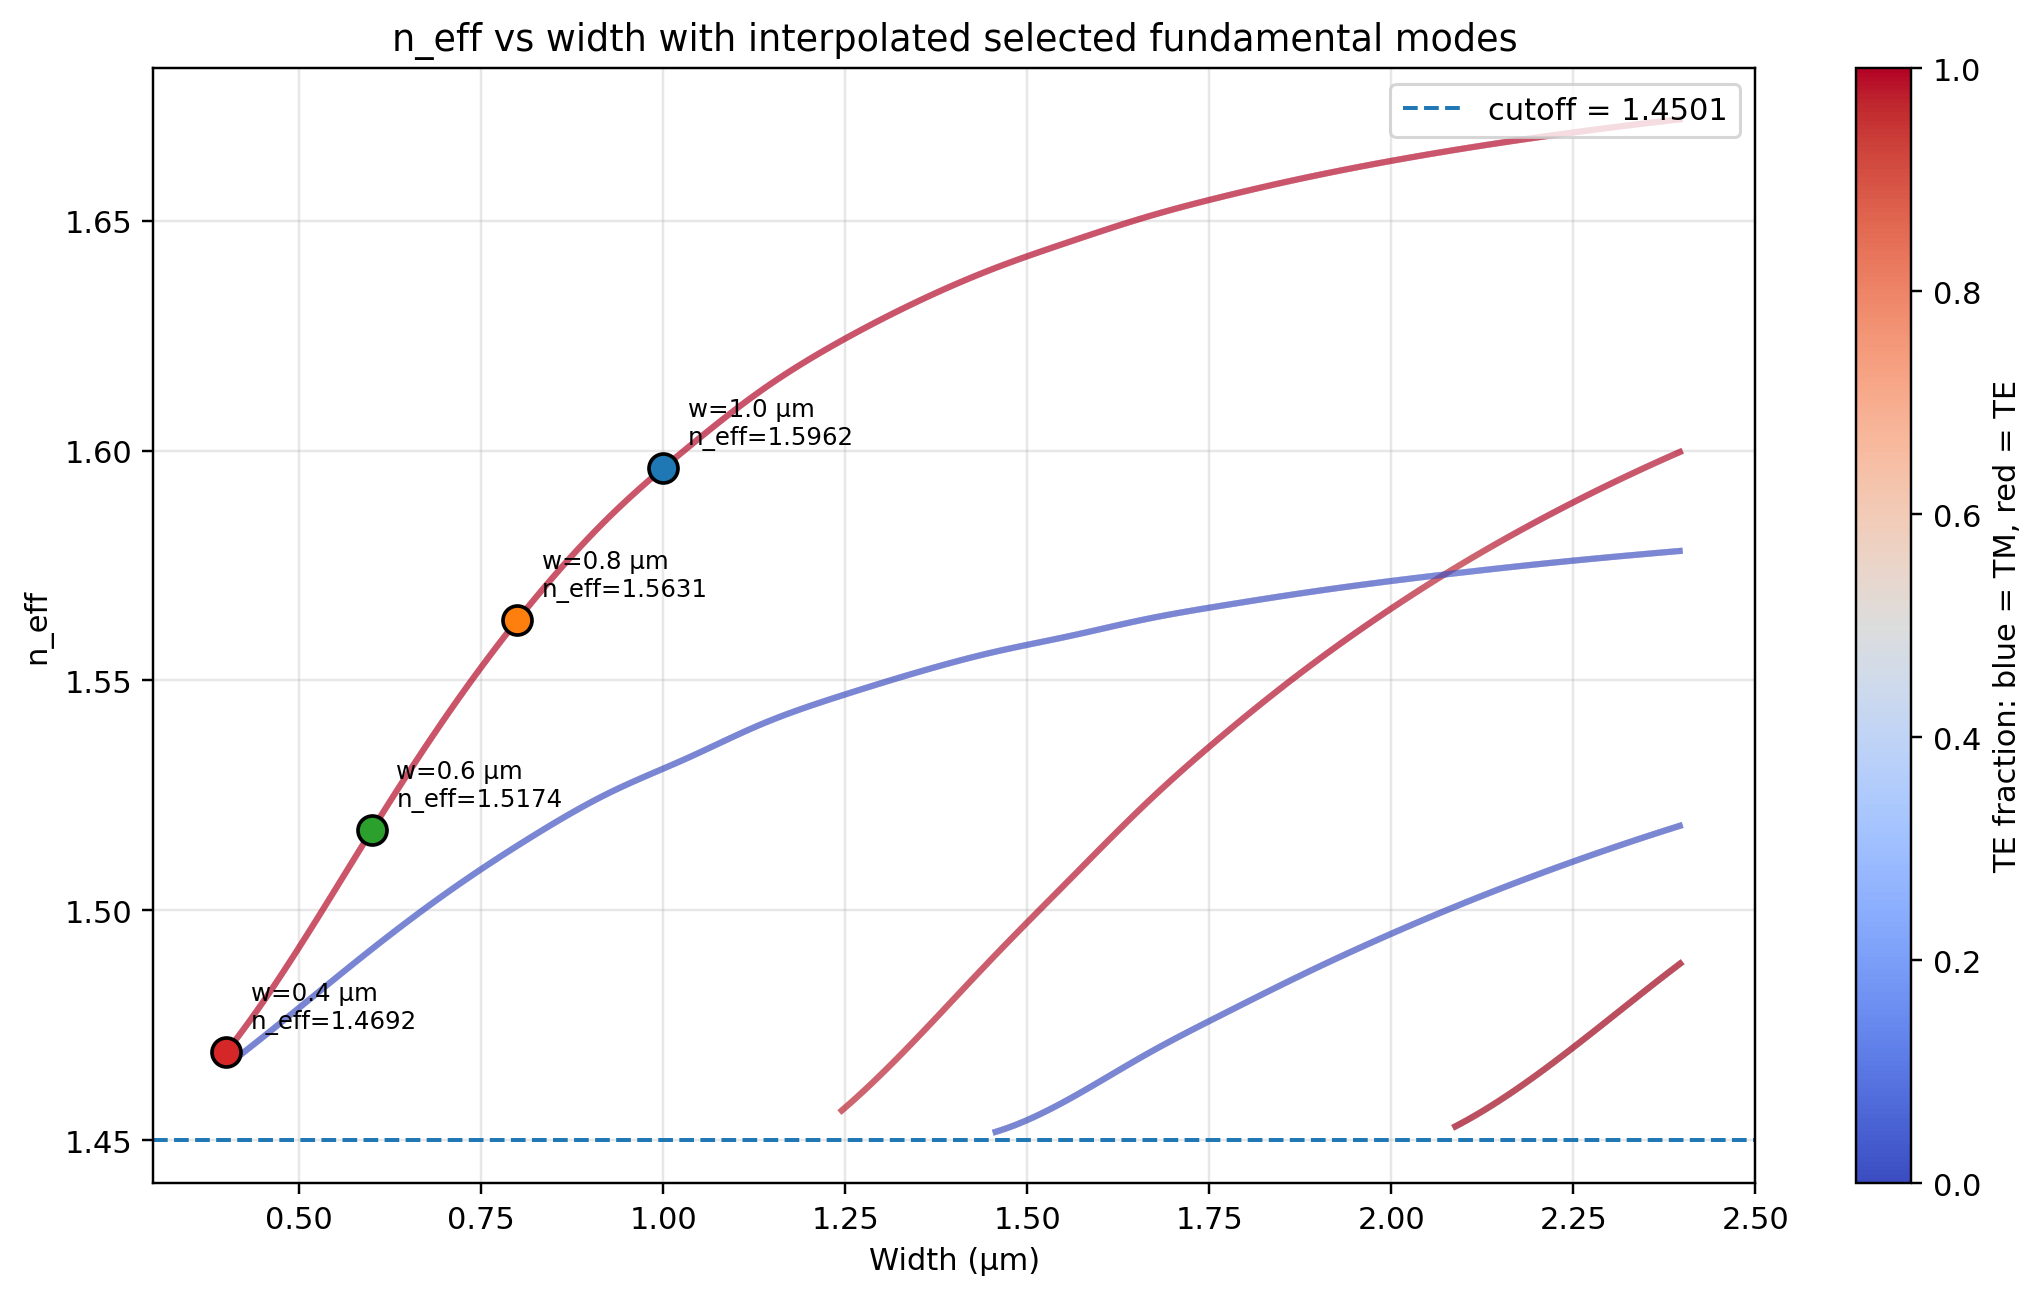

Saved plot: ..\data\processed\width_sweep_selected\all_widths_guided_modes\plots\neff_selected_widths_fundamental_interpolated.png
Saved report: ..\data\processed\width_sweep_selected\all_widths_guided_modes\selected_widths_fundamental_neff_interpolated.csv


In [51]:
# ------------------------------------------------------------
# Selected widths using spline-interpolated fundamental mode
# ------------------------------------------------------------

selected_widths_um = [1.0, 0.8, 0.6, 0.4]

# Choose fundamental branch = highest neff branch.
# Usually this is TE1.
fundamental_branch_name = (
    high_res
    .dropna(subset=["neff"])
    .groupby("tracked_mode")["neff"]
    .max()
    .sort_values(ascending=False)
    .index[0]
)

fund_branch = (
    high_res[high_res["tracked_mode"] == fundamental_branch_name]
    .sort_values("width_um")
    .copy()
)

print("Fundamental branch:", fundamental_branch_name)

selected_rows = []

for w in selected_widths_um:

    if w < fund_branch["width_um"].min() or w > fund_branch["width_um"].max():
        print(f"Width {w:.3f} µm is outside fitted range.")
        continue

    row = {
        "requested_width_um": w,
        "tracked_mode": fundamental_branch_name,
        "polarization": fund_branch["polarization"].iloc[0],
        "mode_number": fund_branch["mode_number"].iloc[0],
    }

    for param in fit_params:
        row[param] = np.interp(
            w,
            fund_branch["width_um"].to_numpy(),
            fund_branch[param].to_numpy(),
        )

    selected_rows.append(row)

selected_fundamental = pd.DataFrame(selected_rows)

selected_report_path = file_out_dir / "selected_widths_fundamental_neff_interpolated.csv"
selected_fundamental.to_csv(selected_report_path, index=False)

selected_fundamental

# ------------------------------------------------------------
# n_eff vs width with selected interpolated fundamental points
# ------------------------------------------------------------

param = "neff"

fig, ax = plt.subplots(figsize=(10, 6), dpi=220)

last_lc = None

for tracked_mode, df_mode in high_res.groupby("tracked_mode"):
    df_mode = df_mode.sort_values("width_um")

    x = df_mode["width_um"].to_numpy()
    y = df_mode[param].to_numpy()
    c = df_mode["TE_fraction"].clip(0, 1).to_numpy()

    lc = plot_colored_line(ax, x, y, c)

    if lc is not None:
        last_lc = lc

for _, row in selected_fundamental.iterrows():
    ax.scatter(
        row["requested_width_um"],
        row["neff"],
        s=90,
        edgecolor="black",
        linewidth=1.2,
        zorder=5,
    )

    ax.annotate(
        f'w={row["requested_width_um"]:.1f} µm\n'
        f'n_eff={row["neff"]:.4f}',
        xy=(row["requested_width_um"], row["neff"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(
    NEFF_CUTOFF,
    linestyle="--",
    linewidth=1.3,
    label=f"cutoff = {NEFF_CUTOFF}",
)

ax.set_xlabel("Width (µm)")
ax.set_ylabel("n_eff")
ax.set_title("n_eff vs width with interpolated selected fundamental modes")
ax.grid(True, alpha=0.3)
ax.legend()

if last_lc is not None:
    cbar = fig.colorbar(last_lc, ax=ax)
    cbar.set_label("TE fraction: blue = TM, red = TE")

fig.tight_layout()

save_path = plot_dir / "neff_selected_widths_fundamental_interpolated.png"
fig.savefig(save_path, dpi=300)
plt.show()

print("Saved plot:", save_path)
print("Saved report:", selected_report_path)